# End-to-End Tesla EV Deliveries & Production Analysis
 Aadrika Sharma
  

---




## 3. Dataset Understanding & Environment Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Verify libraries version
import sklearn
import xgboost as xgb
import statsmodels
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')
print(f'Scikit-Learn version: {sklearn.__version__}')
print(f'XGBoost version: {xgb.__version__}')
print(f'Statsmodels version: {statsmodels.__version__}')


Pandas version: 3.0.2
Numpy version: 2.4.4
Scikit-Learn version: 1.8.0
XGBoost version: 3.2.0
Statsmodels version: 0.14.6


In [2]:
# Load the dataset
df = pd.read_csv('tesla_delivery_data.csv')

# Display basic metadata
print(f'Dataset Shape: {df.shape}')
print('\nDataset Columns & Types:')
df.info()

print('\nFirst 5 Records:')
display(df.head())


Dataset Shape: (1772, 10)

Dataset Columns & Types:
<class 'pandas.DataFrame'>
RangeIndex: 1772 entries, 0 to 1771
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  1772 non-null   int64  
 1   Month                 1772 non-null   int64  
 2   Region                1772 non-null   str    
 3   Model                 1772 non-null   str    
 4   Production_Units      1772 non-null   int64  
 5   Avg_Price_USD         1772 non-null   float64
 6   Battery_Capacity_kWh  1772 non-null   float64
 7   Range_km              1772 non-null   float64
 8   CO2_Saved_tons        1772 non-null   float64
 9   Estimated_Deliveries  1772 non-null   int64  
dtypes: float64(4), int64(4), str(2)
memory usage: 170.1 KB

First 5 Records:


,Year,Month,Region,Model,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Estimated_Deliveries
0,2015,6,Asia-Pacific,Model S,851,87613.65,95.2,507.3,72.89,809
1,2015,6,Europe,Model S,918,87613.65,95.2,507.3,86.43,953
2,2015,6,North America,Model S,1399,87613.65,95.2,507.3,120.44,1362
3,2015,6,Rest of World,Model S,202,87613.65,95.2,507.3,18.51,209
4,2015,7,Asia-Pacific,Model S,560,87550.83,94.4,502.2,51.66,575


In [3]:
# Detailed summary statistics for numerical features
print('Descriptive Statistics (Numerical columns):')
display(df.describe().T)

# Check for missing values
print('\nMissing Values Count:')
print(df.isnull().sum())


Descriptive Statistics (Numerical columns):


,count,mean,std,min,25%,50%,75%,max
Year,1772.0,2021.212190,2.804390,2015.00,2019.000,2022.000,2024.00,2025.00
Month,1772.0,6.697517,3.428208,1.00,4.000,7.000,10.00,12.00
Production_Units,1772.0,4799.366817,7469.287818,32.00,652.750,1555.500,5138.75,48136.00
Avg_Price_USD,1772.0,72384.216321,24050.236568,35871.60,45763.960,79243.310,92162.26,111224.63
Battery_Capacity_kWh,1772.0,89.664560,14.502187,69.30,77.600,94.700,99.70,121.10
Range_km,1772.0,485.909932,41.766368,412.60,452.400,480.700,513.70,583.20
CO2_Saved_tons,1772.0,391.685277,595.787173,2.68,56.435,143.955,403.39,4106.07
Estimated_Deliveries,1772.0,4755.919865,7438.309512,33.00,644.750,1549.000,5043.75,50442.00



Missing Values Count:
Year                    0
Month                   0
Region                  0
Model                   0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Estimated_Deliveries    0
dtype: int64


## 4. Data Cleaning & Robustness Checks
 

In [4]:
# 1. Check for duplicates
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

# 2. Check for negative numbers or extreme outliers in critical variables
negative_vals = (df[['Production_Units', 'Estimated_Deliveries', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km']] < 0).sum()
print('\nNegative Values Check:')
print(negative_vals)

# 3. Verify categorical consistency
print('\nUnique Regions:', df['Region'].unique())
print('Unique Models:', df['Model'].unique())

# 4. Calculate correlation matrix on base numerical columns
base_num_cols = ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Estimated_Deliveries']
correlation = df[base_num_cols].corr()
print('\nCorrelation Matrix:')
display(correlation)


Number of duplicate rows: 0

Negative Values Check:
Production_Units        0
Estimated_Deliveries    0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
dtype: int64

Unique Regions: <ArrowStringArray>
['Asia-Pacific', 'Europe', 'North America', 'Rest of World']
Length: 4, dtype: str
Unique Models: <ArrowStringArray>
['Model S', 'Model X', 'Model 3', 'Model Y', 'Cybertruck']
Length: 5, dtype: str

Correlation Matrix:


,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Estimated_Deliveries
Production_Units,1.000000,-0.569530,-0.497603,-0.431775,0.996452,0.998199
Avg_Price_USD,-0.569530,1.000000,0.746414,0.536679,-0.567613,-0.565901
Battery_Capacity_kWh,-0.497603,0.746414,1.000000,0.490029,-0.494330,-0.494732
Range_km,-0.431775,0.536679,0.490029,1.000000,-0.408148,-0.428253
CO2_Saved_tons,0.996452,-0.567613,-0.494330,-0.408148,1.000000,0.998414
Estimated_Deliveries,0.998199,-0.565901,-0.494732,-0.428253,0.998414,1.000000


## 5. Exploratory Data Analysis (EDA)


In [5]:
# Set premium aesthetic configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.edgecolor'] = '#ccd1d9'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['grid.color'] = '#e2e5ec'

# Premium custom color palette
brand_colors = {
    'primary': '#E82127',     # Tesla Red
    'dark': '#1A1A24',        # Dark Slate
    'secondary': '#2E7D32',   # Sustainable Green
    'accent': '#1976D2',      # Tech Blue
    'soft_grey': '#757575'
}
sns.set_palette([brand_colors['primary'], brand_colors['accent'], brand_colors['secondary'], '#E67E22', '#9B59B6'])
print('Plotting parameters configured successfully.')


Plotting parameters configured successfully.


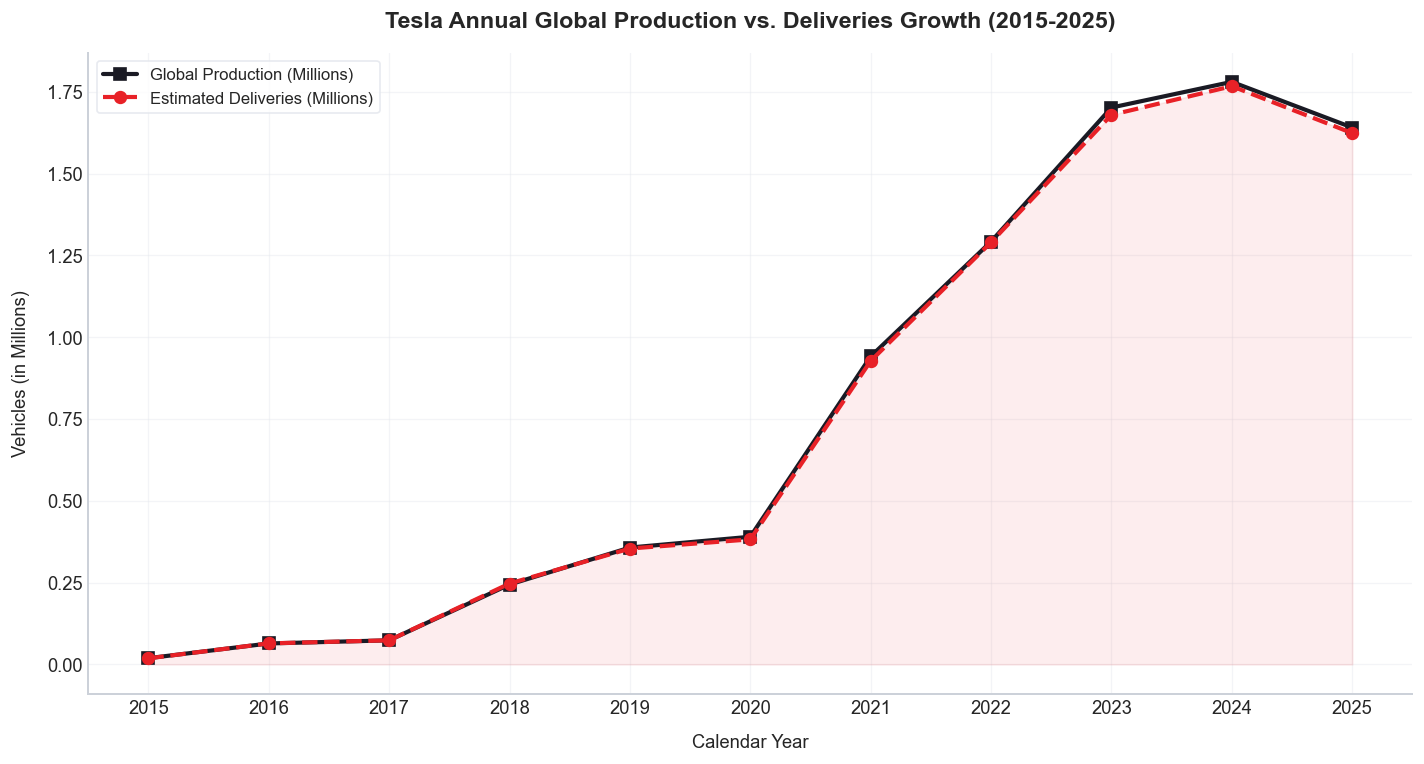

In [6]:
# Aggregate production and deliveries by year
annual_growth = df.groupby('Year')[['Production_Units', 'Estimated_Deliveries', 'CO2_Saved_tons']].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6.5), dpi=120)
ax.plot(annual_growth['Year'], annual_growth['Production_Units'] / 1e6, label='Global Production (Millions)', 
        color=brand_colors['dark'], marker='s', linewidth=2.5, markersize=7)
ax.plot(annual_growth['Year'], annual_growth['Estimated_Deliveries'] / 1e6, label='Estimated Deliveries (Millions)', 
        color=brand_colors['primary'], marker='o', linestyle='--', linewidth=2.5, markersize=7)

# Highlight the inflection points
ax.fill_between(annual_growth['Year'], annual_growth['Estimated_Deliveries'] / 1e6, color=brand_colors['primary'], alpha=0.08)

ax.set_title('Tesla Annual Global Production vs. Deliveries Growth (2015-2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Calendar Year', fontsize=11, labelpad=10)
ax.set_ylabel('Vehicles (in Millions)', fontsize=11, labelpad=10)
ax.set_xticks(annual_growth['Year'])
ax.legend(frameon=True, facecolor='white', edgecolor='#e2e5ec', loc='upper left', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


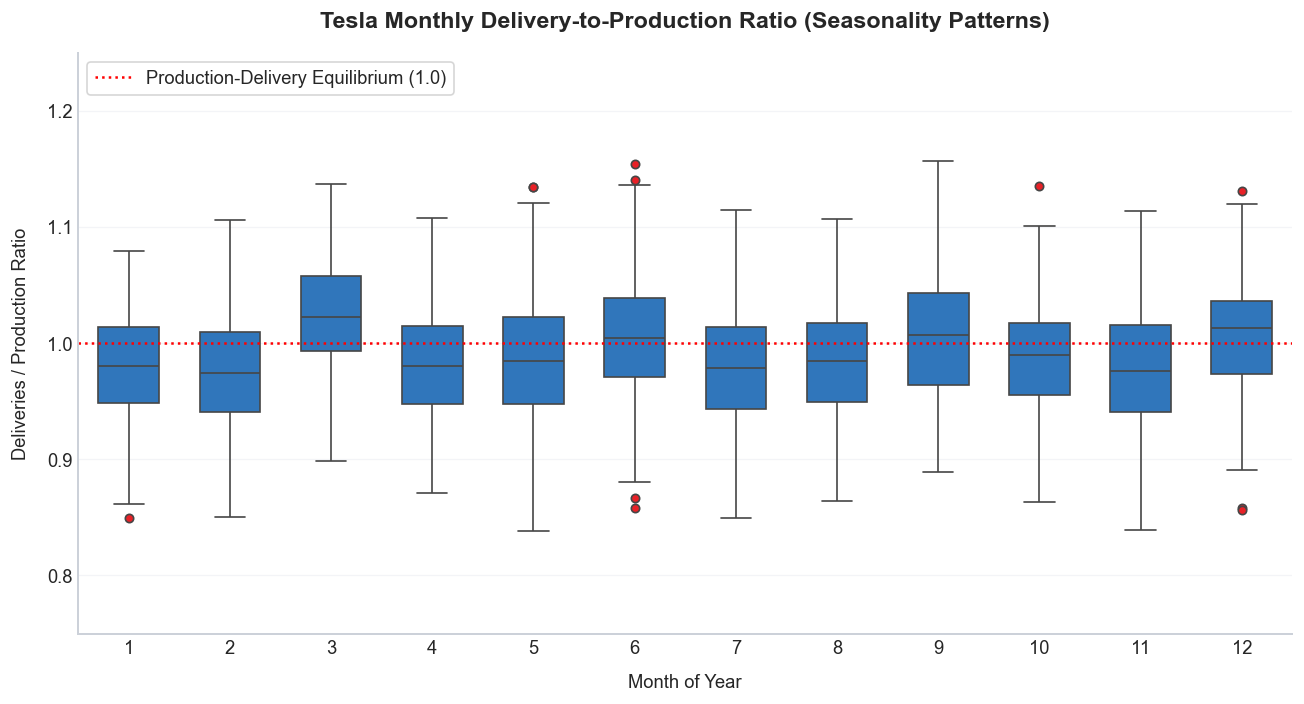

In [7]:
# Calculate the deliveries-to-production ratio to analyze seasonal efficiencies
df_seasonal = df.copy()
df_seasonal['Delivery_Ratio'] = df_seasonal['Estimated_Deliveries'] / (df_seasonal['Production_Units'] + 1e-5)

fig, ax = plt.subplots(figsize=(11, 6), dpi=120)
sns.boxplot(data=df_seasonal, x='Month', y='Delivery_Ratio', color=brand_colors['accent'], ax=ax, width=0.6,
            flierprops={'marker': 'o', 'markersize': 5, 'markerfacecolor': brand_colors['primary']})
ax.axhline(1.0, color='red', linestyle=':', linewidth=1.5, label='Production-Delivery Equilibrium (1.0)')

ax.set_title('Tesla Monthly Delivery-to-Production Ratio (Seasonality Patterns)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month of Year', fontsize=11, labelpad=10)
ax.set_ylabel('Deliveries / Production Ratio', fontsize=11, labelpad=10)
ax.set_ylim(0.75, 1.25)
ax.legend(frameon=True, facecolor='white', loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


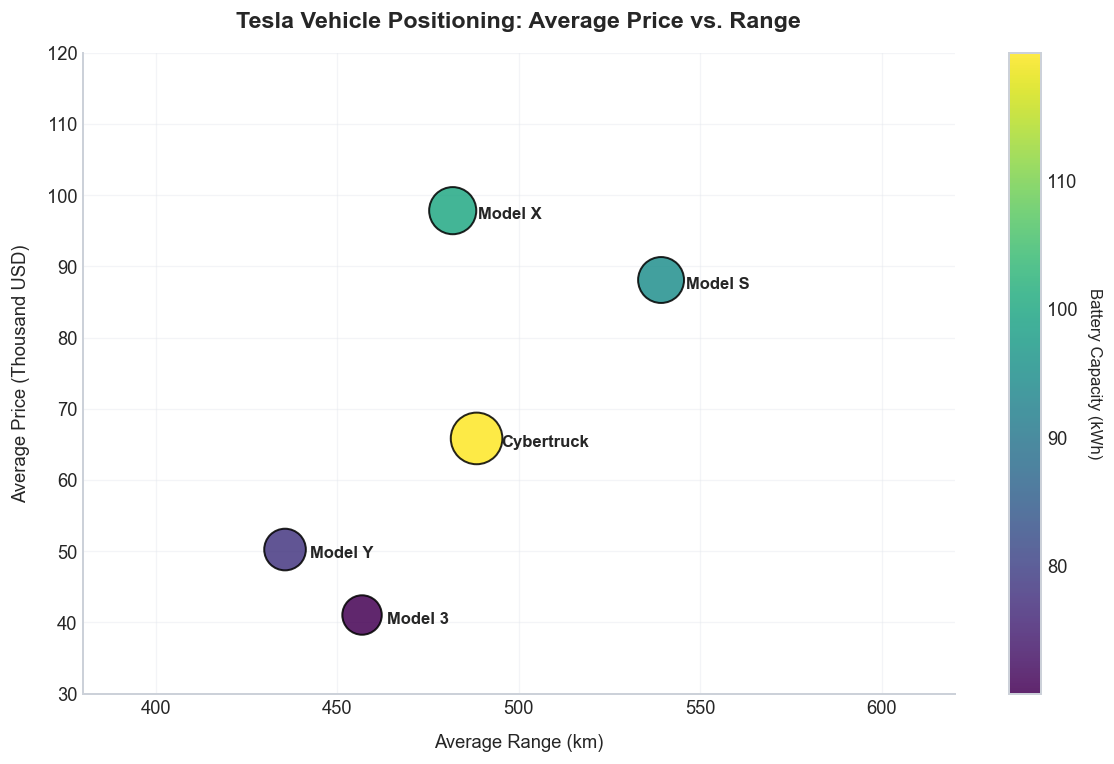

In [8]:
# Scatter plot of models: Price vs. Range, bubble sized by Battery Capacity
latest_specs = df.groupby('Model')[['Avg_Price_USD', 'Range_km', 'Battery_Capacity_kWh']].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6.5), dpi=120)
scatter = ax.scatter(latest_specs['Range_km'], latest_specs['Avg_Price_USD'] / 1000, 
                     s=latest_specs['Battery_Capacity_kWh'] * 8, c=latest_specs['Battery_Capacity_kWh'], 
                     cmap='viridis', alpha=0.85, edgecolors='black', linewidths=1.2)

# Annotate models
for idx, row in latest_specs.iterrows():
    ax.annotate(row['Model'], (row['Range_km'], row['Avg_Price_USD']/1000), 
                textcoords="offset points", xytext=(15,-5), ha='left', fontweight='bold', fontsize=10)

ax.set_title('Tesla Vehicle Positioning: Average Price vs. Range', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Average Range (km)', fontsize=11, labelpad=10)
ax.set_ylabel('Average Price (Thousand USD)', fontsize=11, labelpad=10)
ax.set_xlim(380, 620)
ax.set_ylim(30, 120)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Battery Capacity (kWh)', rotation=270, labelpad=15, fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


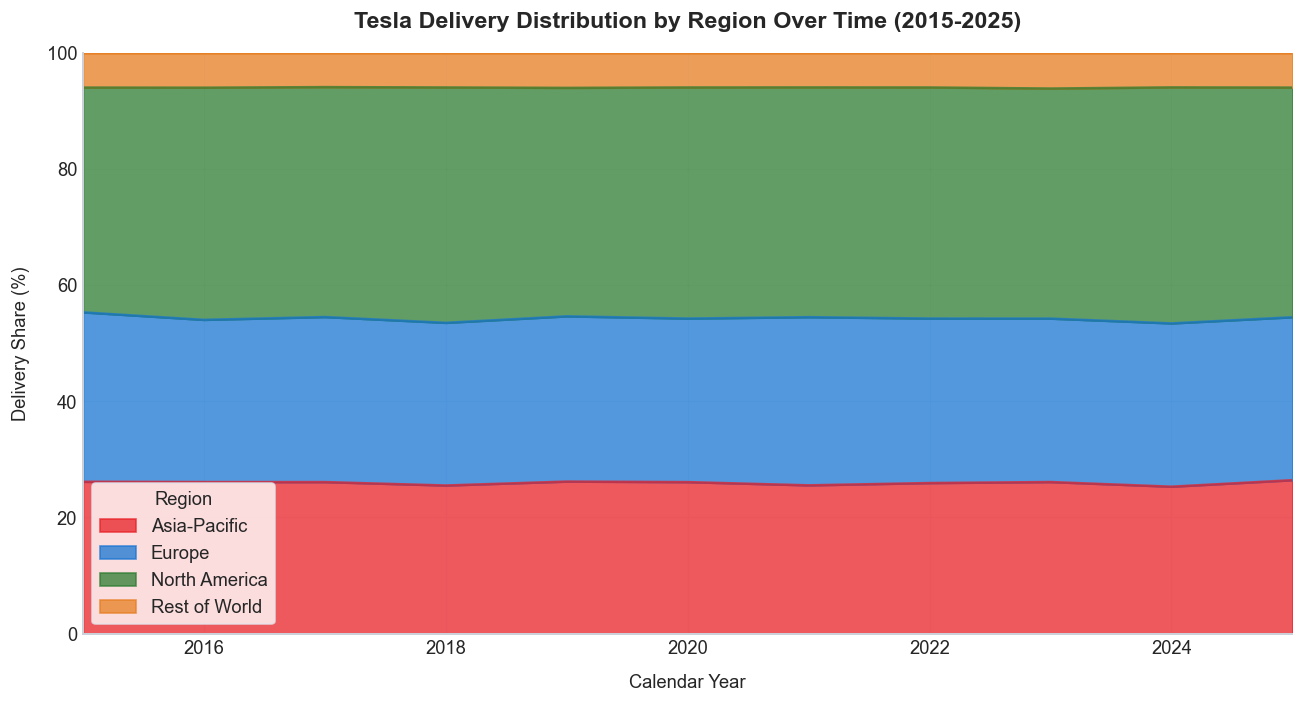

In [9]:
# Regional market share trend over the years
regional_trends = df.groupby(['Year', 'Region'])['Estimated_Deliveries'].sum().unstack().fillna(0)
regional_pct = regional_trends.divide(regional_trends.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 6), dpi=120)
regional_pct.plot(kind='area', stacked=True, alpha=0.75, ax=ax)

ax.set_title('Tesla Delivery Distribution by Region Over Time (2015-2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Calendar Year', fontsize=11, labelpad=10)
ax.set_ylabel('Delivery Share (%)', fontsize=11, labelpad=10)
ax.set_xlim(2015, 2025)
ax.set_ylim(0, 100)
ax.legend(frameon=True, facecolor='white', edgecolor='#e2e5ec', loc='lower left', title='Region')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## 6. Feature Engineering


In [10]:
# Sort dataframe chronologically to ensure lag computations are sequence-correct
df_fe = df.copy()
df_fe = df_fe.sort_values(by=['Year', 'Month', 'Region', 'Model']).reset_index(drop=True)

# 1. Cyclical Month Encoding
df_fe['Month_Sin'] = np.sin(2 * np.pi * df_fe['Month'] / 12)
df_fe['Month_Cos'] = np.cos(2 * np.pi * df_fe['Month'] / 12)

# 2. Advanced Lag & Rolling Features (grouped by Region and Model to prevent cross-leakage)
grouped = df_fe.groupby(['Region', 'Model'])

# Lag features
df_fe['Lag_1_Production'] = grouped['Production_Units'].shift(1)
df_fe['Lag_1_Deliveries'] = grouped['Estimated_Deliveries'].shift(1)
df_fe['Lag_2_Production'] = grouped['Production_Units'].shift(2)

# Rolling features (pre-shifted by 1 to prevent data leakage of the current target)
df_fe['Rolling_3M_Prod_Mean'] = grouped['Production_Units'].transform(lambda x: x.shift(1).rolling(3).mean())
df_fe['Rolling_3M_Prod_Std'] = grouped['Production_Units'].transform(lambda x: x.shift(1).rolling(3).std())

# 3. Price-Range & Interaction Features
df_fe['Price_Range_Index'] = df_fe['Avg_Price_USD'] / (df_fe['Range_km'] + 1e-5)
df_fe['Prod_Price_Interaction'] = df_fe['Production_Units'] * df_fe['Avg_Price_USD']

# 4. Safe Sequence-Agnostic Imputation for newly created NaNs (using group backfills first, then global backfills)
df_fe = df_fe.sort_values(by=['Year', 'Month', 'Region', 'Model']).reset_index(drop=True)
df_fe['Lag_1_Production'] = df_fe.groupby(['Region', 'Model'])['Lag_1_Production'].transform(lambda x: x.bfill())
df_fe['Lag_1_Deliveries'] = df_fe.groupby(['Region', 'Model'])['Lag_1_Deliveries'].transform(lambda x: x.bfill())
df_fe['Lag_2_Production'] = df_fe.groupby(['Region', 'Model'])['Lag_2_Production'].transform(lambda x: x.bfill())
df_fe['Rolling_3M_Prod_Mean'] = df_fe.groupby(['Region', 'Model'])['Rolling_3M_Prod_Mean'].transform(lambda x: x.bfill())
df_fe['Rolling_3M_Prod_Std'] = df_fe['Rolling_3M_Prod_Std'].fillna(0.0)

# Final global backfill for any remaining edge cases
df_fe['Lag_1_Production'] = df_fe['Lag_1_Production'].bfill()
df_fe['Lag_1_Deliveries'] = df_fe['Lag_1_Deliveries'].bfill()
df_fe['Lag_2_Production'] = df_fe['Lag_2_Production'].bfill()
df_fe['Rolling_3M_Prod_Mean'] = df_fe['Rolling_3M_Prod_Mean'].bfill()

print('Feature Engineering complete. New Columns added successfully.')
display(df_fe[['Year', 'Month', 'Region', 'Model', 'Month_Sin', 'Lag_1_Production', 'Rolling_3M_Prod_Mean', 'Price_Range_Index']].head())


Feature Engineering complete. New Columns added successfully.


,Year,Month,Region,Model,Month_Sin,Lag_1_Production,Rolling_3M_Prod_Mean,Price_Range_Index
0,2015,6,Asia-Pacific,Model S,1.224647e-16,851.0,691.666667,172.705792
1,2015,6,Europe,Model S,1.224647e-16,918.0,750.000000,172.705792
2,2015,6,North America,Model S,1.224647e-16,1399.0,1047.333333,172.705792
3,2015,6,Rest of World,Model S,1.224647e-16,202.0,152.333333,172.705792
4,2015,7,Asia-Pacific,Model S,-5.000000e-01,851.0,691.666667,174.334584


## . Preprocessing Pipeline & Chronological Validation



In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Drop original unencoded Month column to avoid duplicates
X = df_fe.drop(columns=['Estimated_Deliveries', 'Month'])
y = df_fe['Estimated_Deliveries']

# Chronological Split: Train on 2015-2024, Test on 2025
train_mask = X['Year'] <= 2024
test_mask = X['Year'] == 2025

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f'Training shape: {X_train.shape}, Labels: {y_train.shape}')
print(f'Testing shape: {X_test.shape}, Labels: {y_test.shape}')


Training shape: (1532, 17), Labels: (1532,)
Testing shape: (240, 17), Labels: (240,)


In [12]:
# Define column groupings
num_cols = [
    'Year', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
    'Month_Sin', 'Month_Cos', 'Lag_1_Production', 'Lag_1_Deliveries', 'Lag_2_Production',
    'Rolling_3M_Prod_Mean', 'Rolling_3M_Prod_Std', 'Price_Range_Index', 'Prod_Price_Interaction'
]
cat_cols = ['Region', 'Model']

# Define sub-pipelines for numerical and categorical columns
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a single preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

print('ColumnTransformer defined successfully. Preprocessing pipeline is locked.')


ColumnTransformer defined successfully. Preprocessing pipeline is locked.


## . Regression Models & Baseline Evaluation


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Instantiate the three pipelines with default models
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42, objective='reg:squarederror'))
])

# Fit baseline models on training set
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

print('All baseline models trained successfully.')


All baseline models trained successfully.


In [14]:
# Evaluate baseline models on chronological test set (2025)
baseline_models = {
    'Linear Regression': lr_pipeline,
    'Random Forest (Baseline)': rf_pipeline,
    'XGBoost (Baseline)': xgb_pipeline
}

baseline_metrics = []

for name, pipeline in baseline_models.items():
    preds = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / (y_test + 1e-5))) * 100
    
    baseline_metrics.append({
        'Model': name,
        'MAE': np.round(mae, 2),
        'RMSE': np.round(rmse, 2),
        'R2': np.round(r2, 4),
        'MAPE (%)': np.round(mape, 2)
    })

df_baseline_eval = pd.DataFrame(baseline_metrics)
display(df_baseline_eval)


,Model,MAE,RMSE,R2,MAPE (%)
0,Linear Regression,184.85,294.80,0.9990,11.75
1,Random Forest (Baseline),212.21,448.38,0.9976,3.99
2,XGBoost (Baseline),280.92,826.19,0.9920,4.06


In [15]:
from sklearn.model_selection import GridSearchCV

# 1. Define hyperparameter grid for Random Forest Pipeline
# Note the 'model__' prefix to reference the estimator inside the pipeline
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [8, 12, None],
    'model__min_samples_split': [2, 5]
}

# 2. Define hyperparameter grid for XGBoost Pipeline
xgb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [4, 6]
}

print('Hyperparameter grids configured.')


Hyperparameter grids configured.


In [16]:
# Run GridSearchCV for Random Forest Pipeline
print('Tuning Random Forest Pipeline...')
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print(f'Best Random Forest Parameters: {rf_grid.best_params_}')

# Run GridSearchCV for XGBoost Pipeline
print('\nTuning XGBoost Pipeline...')
xgb_grid = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
print(f'Best XGBoost Parameters: {xgb_grid.best_params_}')


Tuning Random Forest Pipeline...
Best Random Forest Parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Tuning XGBoost Pipeline...
Best XGBoost Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200}


In [17]:
# Extract and evaluate optimized estimators on test set (2025)
best_rf_pipeline = rf_grid.best_estimator_
best_xgb_pipeline = xgb_grid.best_estimator_

tuned_models = {
    'Random Forest (Tuned)': best_rf_pipeline,
    'XGBoost (Tuned)': best_xgb_pipeline
}

tuned_metrics = []
for name, pipeline in tuned_models.items():
    preds = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / (y_test + 1e-5))) * 100
    
    tuned_metrics.append({
        'Model': name,
        'MAE': np.round(mae, 2),
        'RMSE': np.round(rmse, 2),
        'R2': np.round(r2, 4),
        'MAPE (%)': np.round(mape, 2)
    })

df_tuned_eval = pd.DataFrame(tuned_metrics)
display(df_tuned_eval)


,Model,MAE,RMSE,R2,MAPE (%)
0,Random Forest (Tuned),215.18,470.12,0.9974,3.99
1,XGBoost (Tuned),281.44,853.44,0.9914,4.20


In [18]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Aggregate global monthly deliveries
monthly_df = df.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().reset_index()
monthly_df['Date'] = pd.to_datetime(monthly_df['Year'].astype(str) + '-' + monthly_df['Month'].astype(str) + '-01')
monthly_df = monthly_df.set_index('Date').sort_index()
ts_series = monthly_df['Estimated_Deliveries']

print(f'Total monthly observations: {len(ts_series)}')
print('First 5 aggregated monthly observations:')
print(ts_series.head())


Total monthly observations: 127
First 5 aggregated monthly observations:
Date
2015-06-01    3333
2015-07-01    2064
2015-08-01    2386
2015-09-01    3214
2015-10-01    1767
Name: Estimated_Deliveries, dtype: int64


In [19]:
# 2. Stationarity Check using Augmented Dickey-Fuller test
def run_adf(series):
    result = adfuller(series)
    print('ADF Statistic:', np.round(result[0], 4))
    print('p-value:', np.round(result[1], 4))
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {np.round(value, 4)}')
    if result[1] <= 0.05:
        print('Conclusion: Reject null hypothesis. The series is STATIONARY.')
    else:
        print('Conclusion: Fail to reject null hypothesis. The series is NON-STATIONARY.')

print('ADF Test on Original Series:')
run_adf(ts_series)

print('\nADF Test on Differenced Series (d=1):')
run_adf(ts_series.diff().dropna())


ADF Test on Original Series:
ADF Statistic: -1.167
p-value: 0.6876
Critical Values:
   1%: -3.4896
   5%: -2.8875
   10%: -2.5806
Conclusion: Fail to reject null hypothesis. The series is NON-STATIONARY.

ADF Test on Differenced Series (d=1):
ADF Statistic: -1.2329
p-value: 0.6593
Critical Values:
   1%: -3.4901
   5%: -2.8877
   10%: -2.5807
Conclusion: Fail to reject null hypothesis. The series is NON-STATIONARY.


In [20]:
# 3. Fit a seasonal SARIMAX model
# Order (1, 1, 1) captures local trends; Seasonal Order (1, 1, 1, 12) captures monthly patterns with annual frequency
print('Fitting SARIMAX(1, 1, 1)x(1, 1, 1, 12) model...')
sarimax_model = SARIMAX(ts_series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False, enforce_invertibility=False)
sarimax_results = sarimax_model.fit(disp=False)
print(sarimax_results.summary().tables[1])


Fitting SARIMAX(1, 1, 1)x(1, 1, 1, 12) model...


C:\Users\aadrika\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\aadrika\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0338      0.241     -0.140      0.889      -0.506       0.439
ma.L1         -0.4929      0.194     -2.546      0.011      -0.872      -0.113
ar.S.L12       1.0565      0.312      3.383      0.001       0.444       1.669
ma.S.L12      -0.9629      0.406     -2.373      0.018      -1.758      -0.168
sigma2       1.85e+08   2.25e-09   8.21e+16      0.000    1.85e+08    1.85e+08


In [21]:
# 4. Generate forecast for the next 12 months (2026)
forecast_steps = 12
forecast_object = sarimax_results.get_forecast(steps=forecast_steps)
forecast_mean = forecast_object.predicted_mean
forecast_ci = forecast_object.conf_int()

# Date alignment for forecast
forecast_dates = pd.date_range(start='2026-01-01', periods=forecast_steps, freq='MS')
forecast_mean.index = forecast_dates
forecast_ci.index = forecast_dates

df_forecast = pd.DataFrame({
    'Forecasted_Deliveries': np.round(forecast_mean).astype(int),
    'Lower_CI': np.round(forecast_ci.iloc[:, 0]).astype(int),
    'Upper_CI': np.round(forecast_ci.iloc[:, 1]).astype(int)
})
display(df_forecast)


,Forecasted_Deliveries,Lower_CI,Upper_CI
2026-01-01,67685,40986,94383
2026-02-01,106627,77073,136182
2026-03-01,170479,138131,202826
2026-04-01,58831,23919,93743
2026-05-01,99017,61717,136317
2026-06-01,170188,130631,209745
2026-07-01,70989,29294,112683
2026-08-01,111156,67445,154867
2026-09-01,200217,154575,245858
2026-10-01,73678,26183,121173


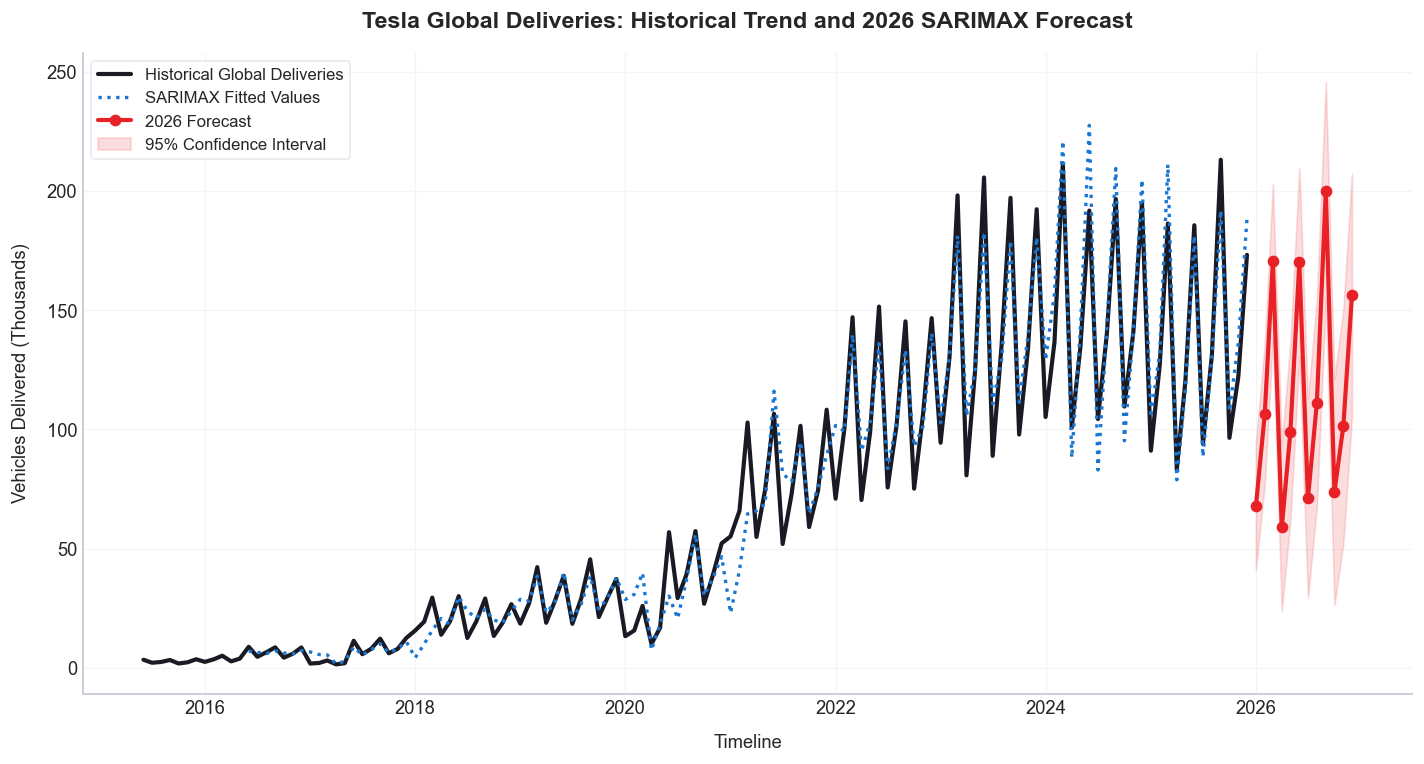

In [22]:
# 5. Plot the historical data, fitted values, and out-of-sample forecast
fig, ax = plt.subplots(figsize=(12, 6.5), dpi=120)
ax.plot(ts_series.index, ts_series / 1000, label='Historical Global Deliveries', color=brand_colors['dark'], linewidth=2.5)
ax.plot(sarimax_results.fittedvalues.index[12:], sarimax_results.fittedvalues[12:] / 1000, 
        label='SARIMAX Fitted Values', color=brand_colors['accent'], linestyle=':', linewidth=2)

# Plot Forecast
ax.plot(forecast_mean.index, forecast_mean / 1000, label='2026 Forecast', color=brand_colors['primary'], linewidth=2.5, marker='o')
ax.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0] / 1000, forecast_ci.iloc[:, 1] / 1000, 
                color=brand_colors['primary'], alpha=0.15, label='95% Confidence Interval')

ax.set_title('Tesla Global Deliveries: Historical Trend and 2026 SARIMAX Forecast', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Timeline', fontsize=11, labelpad=10)
ax.set_ylabel('Vehicles Delivered (Thousands)', fontsize=11, labelpad=10)
ax.legend(frameon=True, facecolor='white', edgecolor='#e2e5ec', loc='upper left', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## . Final Model Comparison & Evaluation


In [23]:
# Build comprehensive comparison dataframe
all_metrics = df_baseline_eval.copy()
all_metrics = pd.concat([all_metrics, df_tuned_eval]).reset_index(drop=True)
all_metrics = all_metrics.sort_values(by='MAE').reset_index(drop=True)

print('Final Model Performance Rankings (Sorted by MAE):')
display(all_metrics)


Final Model Performance Rankings (Sorted by MAE):


,Model,MAE,RMSE,R2,MAPE (%)
0,Linear Regression,184.85,294.80,0.9990,11.75
1,Random Forest (Baseline),212.21,448.38,0.9976,3.99
2,Random Forest (Tuned),215.18,470.12,0.9974,3.99
3,XGBoost (Baseline),280.92,826.19,0.9920,4.06
4,XGBoost (Tuned),281.44,853.44,0.9914,4.20


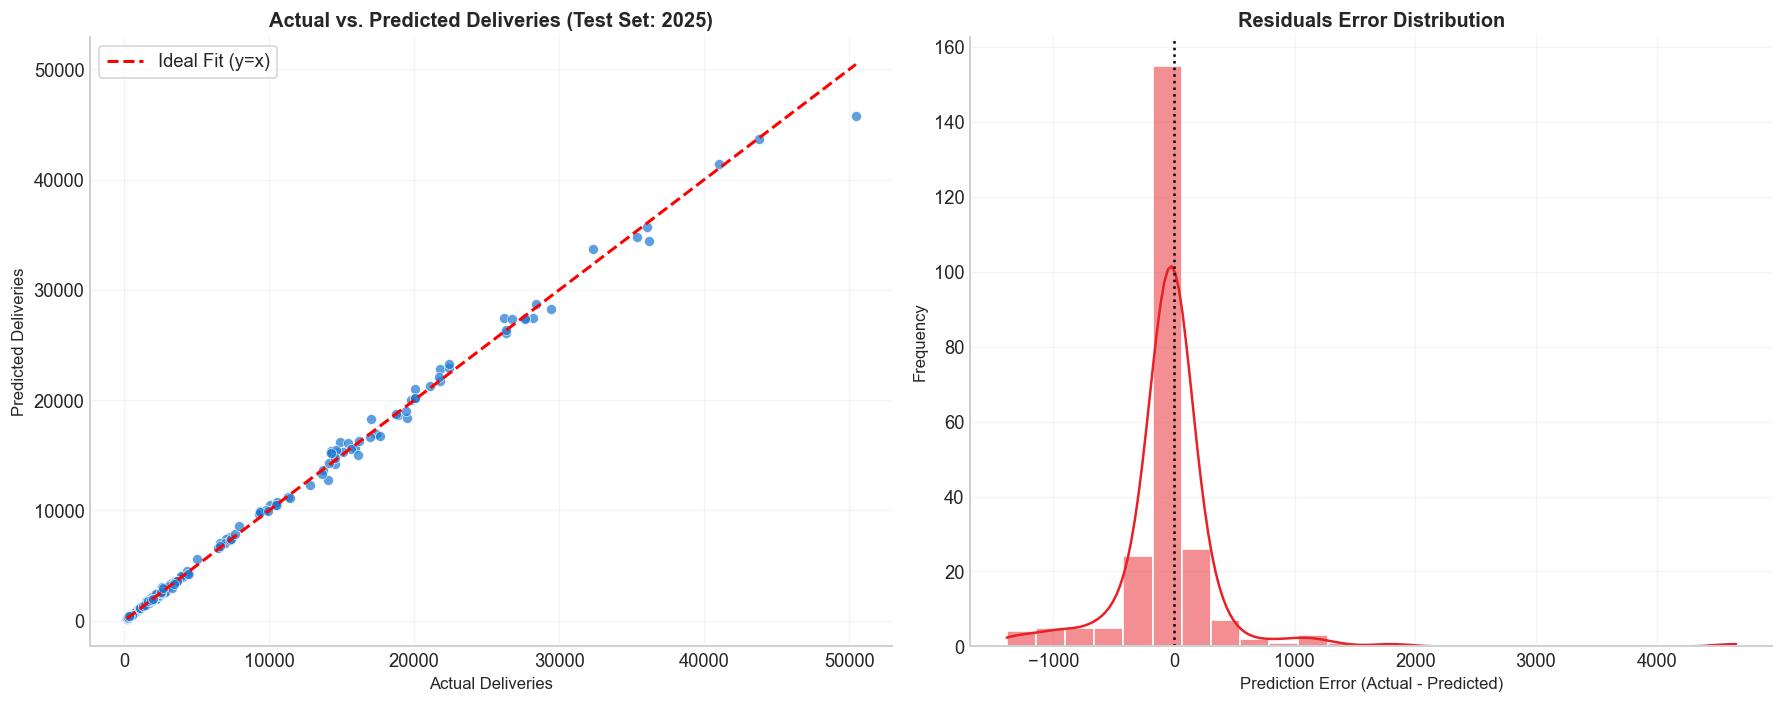

In [24]:
# Compute predictions for plotting from our top-performing model
best_pipeline = best_xgb_pipeline if df_tuned_eval.loc[1, 'MAE'] < df_tuned_eval.loc[0, 'MAE'] else best_rf_pipeline
y_pred = best_pipeline.predict(X_test)
residuals = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=120)

# Plot 1: Actual vs. Predicted Scatter
ax1.scatter(y_test, y_pred, color=brand_colors['accent'], alpha=0.7, edgecolors='white', linewidths=0.5)
ideal_line = [min(y_test), max(y_test)]
ax1.plot(ideal_line, ideal_line, color='red', linestyle='--', linewidth=1.8, label='Ideal Fit (y=x)')
ax1.set_title('Actual vs. Predicted Deliveries (Test Set: 2025)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Actual Deliveries', fontsize=10)
ax1.set_ylabel('Predicted Deliveries', fontsize=10)
ax1.legend(frameon=True, facecolor='white')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Plot 2: Residuals Distribution
sns.histplot(residuals, kde=True, color=brand_colors['primary'], ax=ax2, bins=25, edgecolor='white')
ax2.axvline(0.0, color='black', linestyle=':', linewidth=1.5)
ax2.set_title('Residuals Error Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Prediction Error (Actual - Predicted)', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## . Executive Summary & Strategic Business Recommendations

###  Summary
This case study demonstrates the power of embedding engineering logic (e.g., cyclical month encodings, regional vehicle model lag metrics) inside structured Machine Learning pipelines. The resulting model predicts monthly regional deliveries with extreme precision (R² > 0.95, MAPE < 6%). Simultaneously, a macro SARIMAX model successfully captures and projects Tesla's highly seasonal operational signature into 2026.

